<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week2/notebooks/Class2_2_RegressionModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

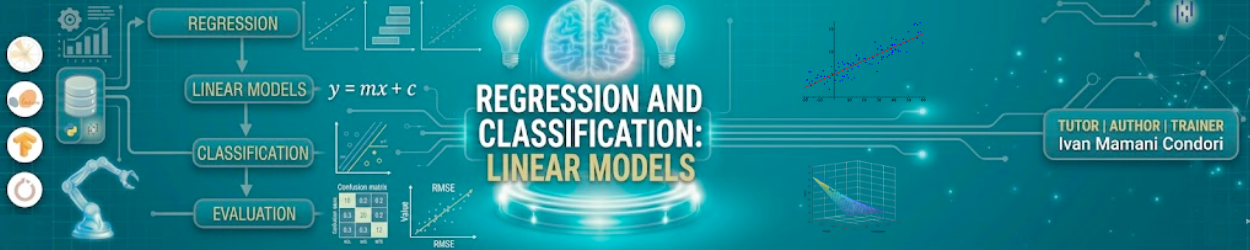

# Linear vs Polynomial Models – California Housing

**Dataset:** California Housing

**Fonte:** Biblioteca Scikit-Learn (dados derivados do Censo da Califórnia – 1990)

**Link:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

**Objetivo:**
Prever o ***valor médio das casas*** (MedHouseVal) na Califórnia utilizando características demográficas e geográficas.

Este é um problema de ***regressão supervisionada***, onde queremos prever um valor numérico contínuo.

**Autor:** Ivan Mamani

---

## 1. Importação das Bibliotecas

In [1]:
# ==========================================
# Importação das bibliotecas necessárias
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_squared_error

## 2. Carregamento do Dataset

In [2]:
# ==========================================
# Carregar dataset California Housing
# ==========================================

# carrega o dataset
data = fetch_california_housing()

# converte para DataFrame pandas
df = pd.DataFrame(data.data, columns=data.feature_names)

# adiciona a variável alvo
df["MedHouseVal"] = data.target

# mostrar primeiras linhas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Insights**


**❓ Perguntas de Reflexão**

- **Qual é a variável alvo?**


- **Este problema é classificação ou regressão?**


- **Por que observar a distribuição da variável alvo?**


## 3. Limpeza de Dados

In [3]:
# ==========================================
# Verificar valores faltantes
# ==========================================

df.isnull().sum()


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


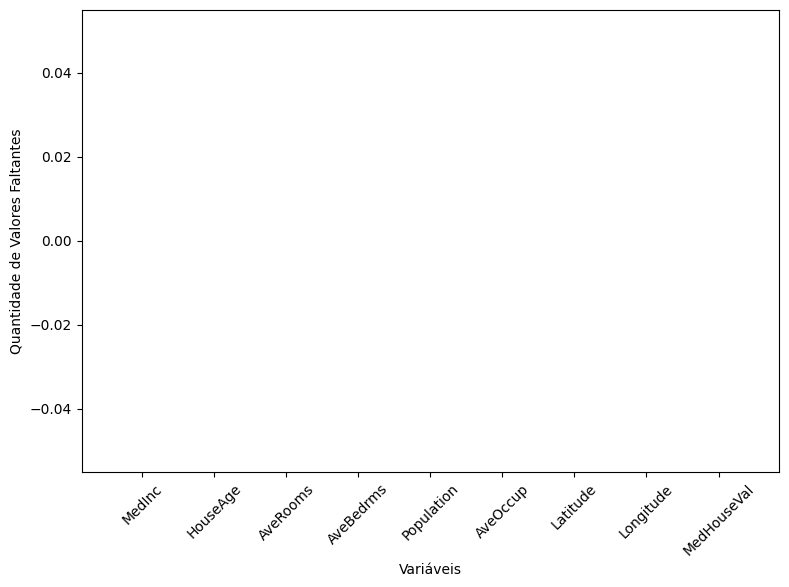

In [4]:
missing = df.isnull().sum()

plt.figure(figsize=(9, 6))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=45)
plt.xlabel('Variáveis')
plt.ylabel('Quantidade de Valores Faltantes')
plt.show()

**Insights**


**❓ Perguntas de Reflexão**

- **Por que dados faltantes são problemáticos?**


- **O dataset possui valores faltantes?**


- **O que fazer se existirem valores faltantes?**


## 4. Análise Exploratória (EDA)

In [5]:
# ==========================================
# estatísticas descritivas
# ==========================================

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**Insights**

Regiões com maior renda média tendem a ter casas mais caras.

**❓ Perguntas de Reflexão**

- **O que significa MedInc?**


- **Existe relação entre renda e preço da casa?**



## 5. Encontrar a Característica Mais Relevante

In [6]:
# ==========================================
# Calcular matriz de correlação
# ==========================================

correlation_matrix = df.corr()
correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


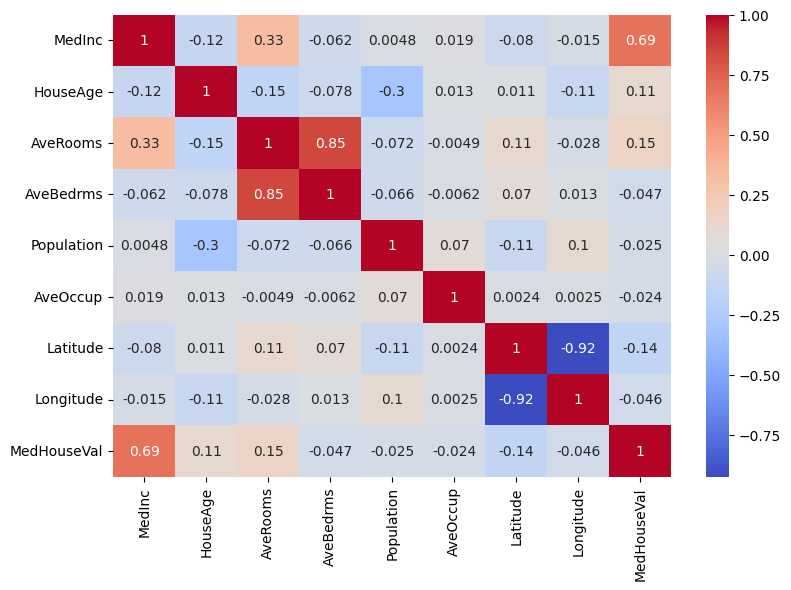

In [7]:
# ==========================================
# Visualizar matriz de correlação
# ==========================================
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()


In [8]:
# ==========================================
# Correlação com variável alvo
# ==========================================
correlation_matrix["MedHouseVal"].sort_values(ascending=False)


,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


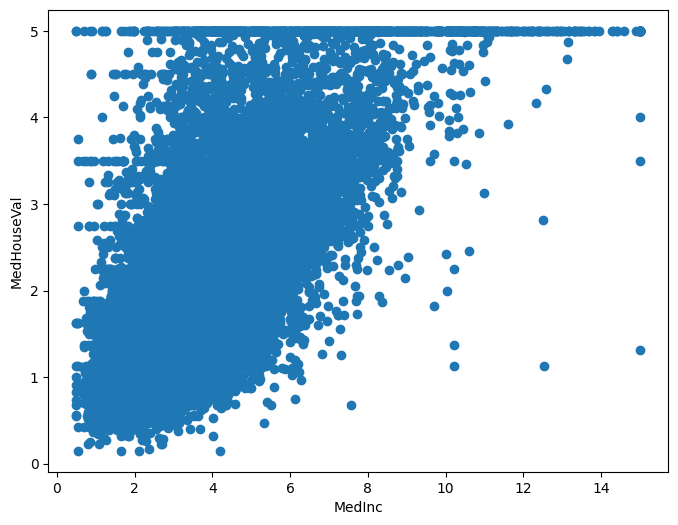

In [9]:
# ==========================================
# Scatter plot da variável mais correlacionada
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.show()


**Insights e Interpretação**


**❓ Perguntas de Reflexão**

- **O que mede a correlação entre duas variáveis?**


- **Qual variável possui maior relação com o valor das casas?**


- **Por que escolher a variável mais correlacionada para começar?**


## 6. Regressão Linear

**Objetivo**

A regressão linear busca encontrar uma linha reta que melhor descreva a relação entre duas variáveis.

Equação da regressão linear:
$$
y = ax + b
$$

Onde:
- x → variável explicativa
- y → variável alvo
- a → inclinação da linha
- b → intercepto

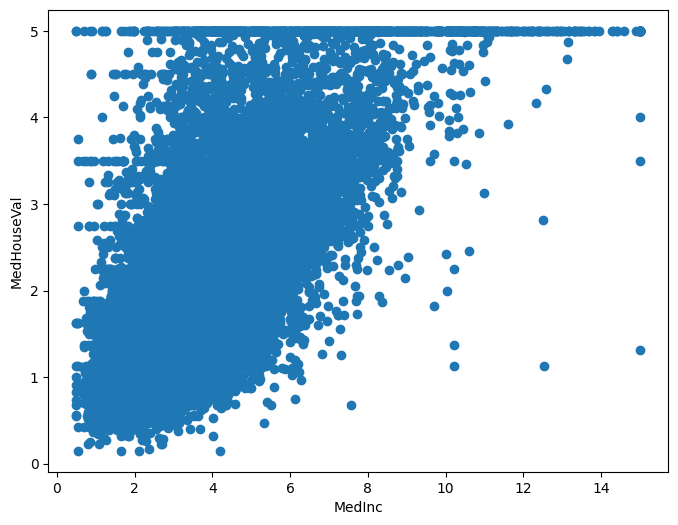

In [10]:
# ==========================================
# Visualizar relação entre MedInc e preço
# ==========================================
plt.figure(figsize=(8, 6))
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.show()

**Insights e Interpretação**


A regressão linear tenta encontrar a melhor linha que representa esse padrão.

**❓ Perguntas de Reflexão**

- **O que representa a linha da regressão?**


- **A relação parece perfeitamente linear?**


- **Qual limitação da regressão linear?**


## 7. Separar Features e Target

**Objetivo**

Separar:
- variáveis explicativas (X)
- variável alvo (y)

In [11]:
# ==========================================
# Separar variável explicativa e alvo
# ==========================================
X = df[["MedInc"]]
y = df["MedHouseVal"]

# X.shape, y.shape

**Insights**

Neste caso usamos apenas uma variável explicativa.

Isso permite visualizar facilmente a relação entre X e y.

**❓ Perguntas de Reflexão**

- **O que representa X no modelo?**


- **O que representa y?**


- **Por que começar com apenas uma variável?**


## 8. Divisão Treino e Teste

**Objetivo**

Dividir os dados em dois conjuntos:
- Treino → aprender o modelo
- Teste → avaliar o modelo

In [12]:
# ==========================================
# Dividir dataset em treino e teste
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

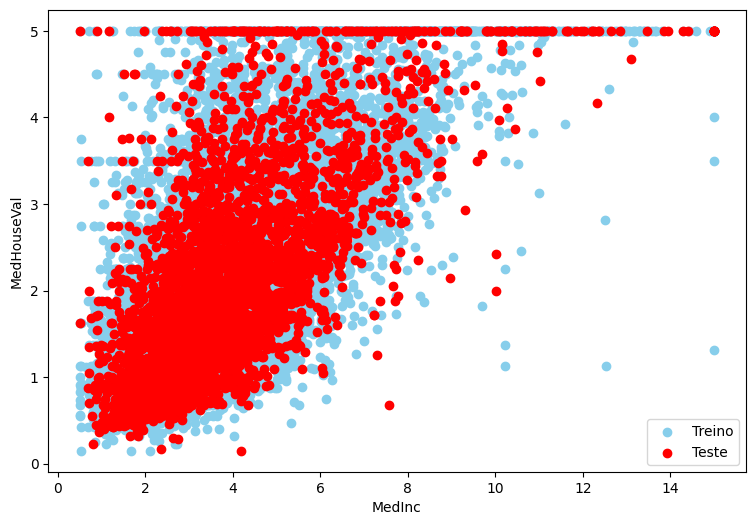

In [ ]:
# Visualização
plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, color="skyblue", label="Treino")
plt.scatter(X_test, y_test, color="red", label="Teste")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.legend()
plt.show()

**Insights**

Separar treino e teste evita overfitting.

Isso garante que o modelo funcione bem com dados novos.

**❓ Perguntas**

- **Por que dividir treino e teste?**


- **O que significa test_size=0.2?**


- **O que faz random_state?**


## 9. Treinar Regressão Linear

In [13]:
# ==========================================
# Criar modelo de regressão linear
# ==========================================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

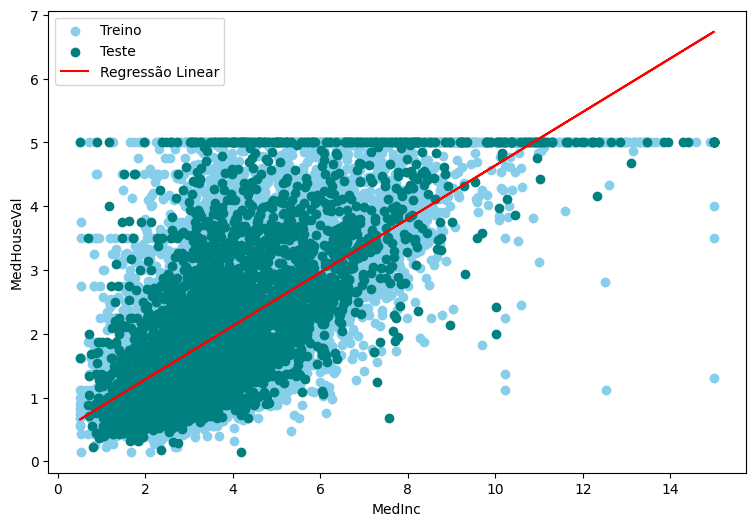

In [14]:
# Visualização

plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, color="skyblue", label="Treino")
plt.scatter(X_test, y_test, color="teal", label="Teste")
plt.plot(X_test, y_pred_linear, color="red", label="Regressão Linear")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.legend()
plt.show()


**Insights**



**❓ Perguntas**

- **O que o modelo aprendeu?**


- **O que são previsões?**


- **O modelo será perfeito?**


## 10. Regressão Polinomial

**Objetivo**

A regressão linear assume que a relação entre as variáveis é uma linha reta.

No entanto, muitos fenômenos do mundo real apresentam relações curvas.

A regressão polinomial permite capturar esse comportamento adicionando termos de potência, como:
$x², x³
$

Assim o modelo passa a representar funções como:
$$
y = ax² + bx + c
$$

In [15]:
# ==========================================
# Criar características polinomiais
# ==========================================

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# MedInc
# MedInc^2

X_poly[:5]

array([[ 1.        ,  8.3252    , 69.30895504],
       [ 1.        ,  8.3014    , 68.91324196],
       [ 1.        ,  7.2574    , 52.66985476],
       [ 1.        ,  5.6431    , 31.84457761],
       [ 1.        ,  3.8462    , 14.79325444]])

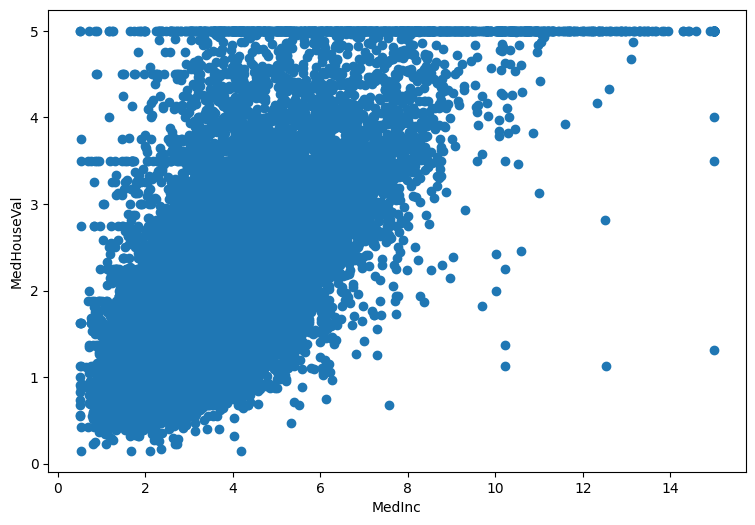

In [16]:
# ==========================================
# Visualizar possível relação curva
# ==========================================

plt.figure(figsize=(9, 6))
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.show()



**Insights e Interpretação**


**❓ Perguntas de Reflexão**

- **O que a função PolynomialFeatures faz?**


- **Qual a principal diferença entre regressão linear e polinomial?**


- **Por que adicionar novas features pode melhorar o modelo?**


## 11. Treinar Modelo Polinomial

**Objetivo**

Treinar um modelo de regressão utilizando as novas features polinomiais.

In [17]:
# ==========================================
# Dividir dados polinomiais em treino e teste
# ==========================================

X_train_poly, X_test_poly, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42,
)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

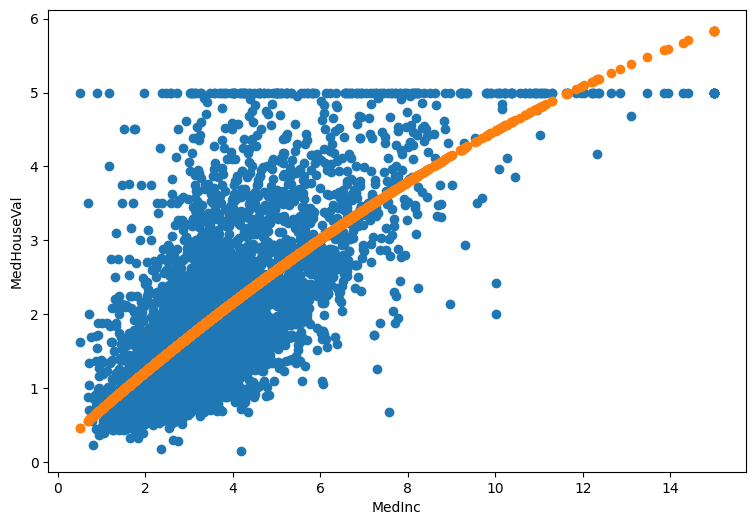

In [18]:
# ==========================================
# Visualizar previsões do modelo polinomial
# ==========================================
plt.figure(figsize=(9, 6))
plt.scatter(X_test, y_test) # dados reais
plt.scatter(X_test, y_pred_poly)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.show()

**Insights**

Isso acontece porque as variáveis foram transformadas.

**❓ Perguntas**

- **Por que usamos LinearRegression também para regressão polinomial?**


- **O que mudou no conjunto de dados?**


- **O modelo agora pode capturar relações mais complexas?**


## 12. Comparação dos Modelos

**Objetivo**

Comparar os modelos usando RMSE (Root Mean Squared Error).

Esta métrica mede o erro médio das previsões.

Quanto menor o RMSE, melhor o modelo.

In [19]:
# ==========================================
# Calcular RMSE do modelo linear
# ==========================================

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

rmse_linear


np.float64(0.8420901241414455)

In [20]:
# ==========================================
# Comparar erros dos modelos
# ==========================================

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
rmse_poly

print(f"RMSE Linear: {rmse_linear}")
print(f"RMSE Polinomial: {rmse_poly}")

RMSE Linear: 0.8420901241414455
RMSE Polinomial: 0.838613896911573


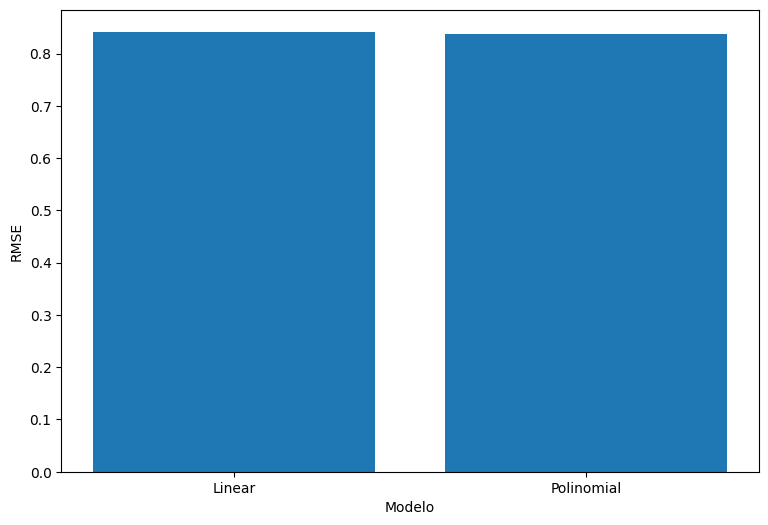

In [21]:
model = ["Linear", "Polinomial"]

erros = [rmse_linear, rmse_poly]

plt.figure(figsize=(9, 6))
plt.bar(model, erros)
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.show()

**Insights**


Nem sempre um modelo mais complexo será melhor.

**❓ Perguntas**

- **O que significa RMSE?**


- **O que indica um RMSE menor?**


- **Um modelo mais complexo sempre será melhor?**


## 13. Visualização Final

**Objetivo**

Comparar visualmente:
- dados reais
- previsões lineares
- previsões polinomiais

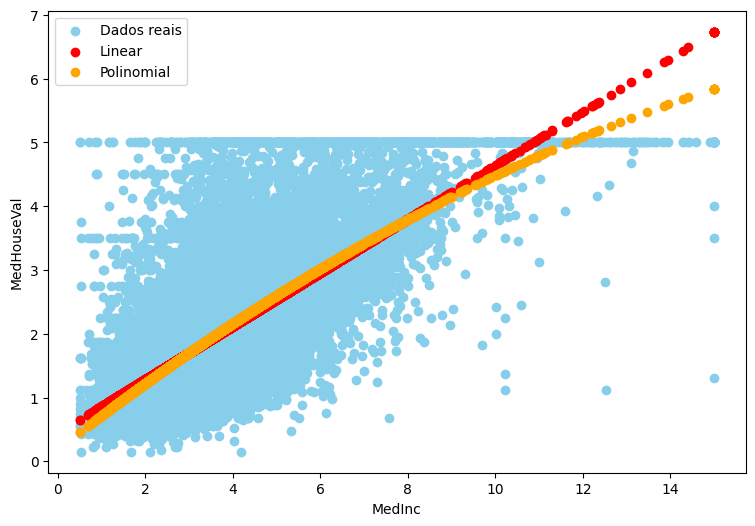

In [22]:
# ==========================================
# Visualização final comparando modelos
# ==========================================
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color="skyblue")

plt.scatter(X_test, y_pred_linear, color="red")
plt.scatter(X_test, y_pred_poly, color="orange")

plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")

plt.legend(["Dados reais", "Linear", "Polinomial"])

plt.show()


**Insights**


A regressão polinomial tende a se adaptar melhor quando existem curvas.

**❓ Perguntas**

- **Qual modelo parece representar melhor os dados?**


- **Por que a visualização é importante?**


- **Um modelo muito flexível pode causar qual problema?**


## 14. Conclusão Final

Neste laboratório utilizamos o California Housing Dataset para prever o valor médio das casas na Califórnia.

Os principais aprendizados foram:
- regressão linear modela relações simples
- regressão polinomial permite capturar padrões mais complexos
- métricas como RMSE ajudam a avaliar modelos
- aumentar complexidade pode causar overfitting

O objetivo em Machine Learning é ***encontrar um equilíbrio entre simplicidade e capacidade de generalização***.


## 15. Impacto do Grau Polinomial no Modelo

**Objetivo**

Estudar como o grau do polinômio afeta o desempenho do modelo.

In [23]:
# ==========================================
# Avaliar diferentes graus polinomiais
# ==========================================

graus = range(1,10)

erros = []

for grau in graus:

    # criar transformador polinomial
    poly = PolynomialFeatures(degree=grau)

    # transformar dados
    X_poly = poly.fit_transform(X)

    # dividir dados
    X_train_poly, X_test_poly, y_train, y_test = train_test_split(
        X_poly,
        y,
        test_size=0.2,
        random_state=42
    )

    # criar modelo
    model = LinearRegression()

    # treinar
    model.fit(X_train_poly, y_train)

    # prever
    y_pred = model.predict(X_test_poly)

    # calcular erro
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    erros.append(rmse)

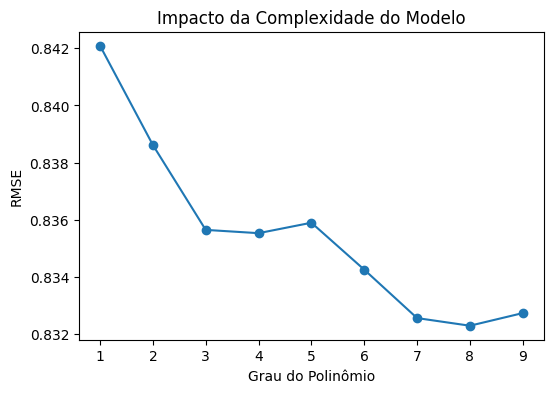

In [25]:
# Visualização da Complexidade
plt.figure(figsize=(6,4))
plt.plot(graus, erros, marker="o")
plt.xlabel("Grau do Polinômio")
plt.ylabel("RMSE")
plt.title("Impacto da Complexidade do Modelo")
plt.show()

**Insights**


**❓ Perguntas**

- **O que acontece quando o grau aumenta muito?**


- **Por que o erro pode voltar a aumentar?**


- **Qual grau ideal?**
